In [82]:
from scipy.integrate import solve_ivp
import numpy as np
import torch
from sbalign.training.diffusivity import *
import matplotlib.pyplot as plt

num_k=5
H=0.5

gamma_min = None
gamma_max = 20.0
g_max = 1.0

fbb = FractionalSchrödingerBridge(H=H, K=num_k, gamma_min=gamma_min,gamma_max=gamma_max,g_max=g_max)

omega = fbb.omega 
gamma = fbb.gamma

normalize variance with 1.0
dtype torch.float32
g_max=1.0


In [73]:
def covX(s,t,T, omega, gamma, g):

    # compute cov(X(t),X(T)|Z_s=z) with s<t<=T 
    # expects s,t,T of shape (batch_size1,batch_size2,1,1)
    # expects omega,gamma of shape (1,K)

    omega_ij = omega[:,None,:,None]*omega[:,None,None,:]
    gamma_i = gamma[:,None,:,None]
    gamma_j = gamma[:,None,None,:]
    gamma_ij =  gamma_i + gamma_j

    weight = omega_ij/ gamma_ij

    S = weight * (torch.exp(t*gamma_ij) -torch.exp(s*(gamma_ij))) * torch.exp(-T*gamma_j - t*gamma_i) 

    return g**2 * (torch.sum(S,axis=(2,3)))

def covYX(s,t,T, omega, gamma, g):

    # compute cov(Y(t),X(T)|Z_s=z) with s<t<=T 
    # expects s,t,T of shape (batch_size1,batch_size2,1,1)
    # expects omega,gamma of shape (1,K)

    gamma_l = gamma[:,None,:,None] #dim of Y_l
    omega_k = omega[:,None,None,:]
    gamma_k = gamma[:,None,None,:]

    weight = omega_k/(gamma_l+gamma_k) #dim of omega_k in X
    S = weight *(torch.exp(t*(gamma_l+gamma_k)) -1)*torch.exp(-t*gamma_l-T*gamma_k)

    return g * torch.sum(S,axis=3)

def covY(s,t,T, gamma):

    # compute cov(Y(t),Y(T)|Z_s=z) with s<t<=T 
    # expects s,t,T of shape (batch_size1,batch_size2,1,1)
    # expects omega,gamma of shape (1,K)

    gamma_i = gamma[:,None,:,None]
    gamma_j = gamma[:,None,None,:]
    gamma_ij =  gamma_i + gamma_j

    return (torch.exp(-T*gamma_j-t*gamma_i)*(torch.exp(t*gamma_ij)-torch.exp(s*gamma_ij)))/gamma_ij

def covZ(t,T, omega, gamma, g, s=None, eps=1e-4):

    # compute cov(X(t),X(T)|Z_s=z) with s<t<=T 
    # expects s,t,T of shape (batch_size1,batch_size2,)
    # expects omega,gamma of shape (1,K)

    t = t[:,:,None,None] 
    T = T[:,:,None,None]
    s = torch.zeros_like(t) if s is None else s[:,:,None,None]

    K = omega.shape[1]
    bs1 = t.shape[0]
    bs2 = t.shape[1]
    Sig = torch.zeros(bs1, bs2, K+1,K+1)
    
    Sig_xy = covYX(s,t,T, omega, gamma, g)
    Sig[:,:,0,0] = covX(s,t,T, omega, gamma, g)
    Sig[:,:,1:,0] = Sig_xy
    Sig[:,:,0,1:] = Sig_xy
    Sig[:,:,1:,1:] = covY(s,t,T, gamma)

    # I_eps = torch.eye(K, K)[None, :, :] * torch.ones((bs, K, K)) * eps * torch.exp(-2 * gamma * t[:,:,0])[:, :, None]
    # Sig[:,1:,1:] = Sig[:,1:,1:] + I_eps
    # Sig[:,0,0] += eps

    Sig = Sig + torch.eye(K+1, K+1)[None,None, :, :] * torch.ones((bs1, bs2, K+1, K+1)) * eps

    assert ((torch.diag(Sig[0,0])>0).all()), f'Found negativ variance: \n {torch.diag(Sig[0,0])<0}'

    return Sig

# def cond_var(t,T,omega,gamma,g):

#     t = t[:,:,None]
#     T = T[:,:,None]

#     omega_i = omega[:,None,:]
#     omega_j = omega[:,:,None]
#     gamma_i = gamma[:,None,:]
#     gamma_j = gamma[:,:,None]

#     return g * torch.sum((omega_i * omega_j)/(gamma_i+gamma_j) * (1-torch.exp(-(gamma_i+gamma_j)*(T-t))),dim=(1,2))

def sample_pinned(t,T,x0,xT,omega,gamma,g):

    K = omega.shape[1]
    bs1 = t.shape[0]
    bs2 = t.shape[1]

    t = t[:,:,None,None] 
    T = T[:,:,None,None]
    s = torch.zeros_like(t)

    mu = torch.zeros(x0.shape+(K+1,))
    mu[:,:,0] = x0

    Sig_zx = torch.zeros(bs1,bs2,K+1)
    
    Sig_zx[:,:,0] = covX(s,t,T, omega, gamma, g)
    Sig_zx[:,:,1:] = covYX(s,t,T, omega, gamma, g)

    var = covX(s,T,T, omega, gamma, g)
    mu_bar = mu + (1/var[:,:,None]) * Sig_zx * ((xT-x0)[:,:,None])

    Sig_bar = covZ(t[:,:,0,0],t[:,:,0,0],omega,gamma,g) - (1/var[:,:,None,None]) * (Sig_zx[:,:,:,None] * Sig_zx[:,:,None,:])

    Sig_bar_flat = einops.rearrange(Sig_bar, 'bs1 bs2 K L -> (bs1 bs2) K L', bs1=bs1, bs2=bs2)
    assert (Sig_bar_flat.transpose(1, 2) == Sig_bar_flat).all(), f'Covariance is not symmetric'

    noise_flat = sample_from_batch_multivariate_normal(Sig_bar_flat,c=1,h=1,w=1,batch_size=int(bs1*bs2), aug_dim=K+1)[:,0,0,0,:]
    noise = einops.rearrange(noise_flat, '(bs1 bs2) K -> bs1 bs2 K', bs1=bs1, bs2=bs2)

    return mu_bar + noise

In [74]:
def score_fn(t,T,x,Y,xT,omega, gamma, g):

    mu = meanX(t,T,x,Y,omega,gamma,g)
    var = covX(t,T,T, omega, gamma, g)
    score_x = (xT - mu)/var
    
    scale = torch.ones(1,1,omega.shape[1]+1)
    scale[:,:,1:] = omega[:,None,:] * zeta(t,T,gamma,g) 

    return scale * score_x[:,:,None]

def zeta(s,t,gamma,g):

    # expects s,t of shape (batch_size1,batch_size2,1) and s<=t
    # expects omega and gamma of shape (1,1,K)

    return g*(torch.exp(-gamma*(t-s))-1)

def meanX(s,t,x,Y,omega,gamma,g):

    # compute E[X(t)|Z_s=z) with s<t - Z_s = (x,Y) 
    # mean of X_T conditioned on Z_t = (x,Y)

    s = s[:,:,None]
    t = t[:,:,None]
    gamma = gamma[:,None,:]
    omega = omega[:,None,:]

    weight = omega * zeta(s,t,gamma,g) 
    y_part = (torch.sum(weight*Y, dim=-1)) 

    return x + y_part

def meanY(s,t,gamma):

    # compute E[Y(t)|Z_s=z) with s<t 
    # mean of X_T conditioned on Z_t = (x,Y)

    s = s[:,:,None]
    t = t[:,:,None]
    gamma = gamma[:,None,:]

    return torch.exp(-gamma*(t-s)) * Y

def meanZ(s,t,x,Y,omega,gamma,g):

    mean_x = meanX(s,t,x,Y,omega,gamma,g)
    mean_y = meanY(s,t,gamma)
    
    return torch.cat([mean_x.unsqueeze(-1),mean_y],dim=-1)

In [75]:
def mu(t):
    return torch.zeros_like(t)

def g(t):
    return torch.tensor(g_max)

def numpy_compute_YiYj(t, gamma):
    gamma_i, gamma_j = (
        gamma[0, :, None].cpu().numpy(),
        gamma[0, None, :].cpu().numpy(),
    )
    return (1 - np.exp(-(gamma_i + gamma_j) * t.cpu().numpy())) / (
        gamma_i + gamma_j
    )

def func(t, S, num_k=5):
    t = torch.as_tensor(t)
    A = np.zeros((num_k + 1, num_k + 1))
    A[0, 0] = 2 * mu(t).cpu().numpy()
    A[0, 1:] = -2 * (g(t) * omega[0] * gamma[0]).cpu().numpy()
    A[1:, 1:] = np.diag((mu(t) - gamma[0]).cpu().numpy())
    b = np.zeros(num_k + 1)
    b[0] = (omega[0].cpu().numpy().sum() * g(t).cpu().numpy()) ** 2
    b[1:] = g(t).cpu().numpy() * (
        omega[0].cpu().numpy().sum()
        - numpy_compute_YiYj(t,gamma) @ (omega[0] * gamma[0]).cpu().numpy()
    )

    return A @ S + b

def get_result(t, num_k, gamma):
    S_0 = np.zeros(num_k + 1)
    result = solve_ivp(func, (0., 1.), S_0, dense_output=True)
    S = result.sol(t)
    cov = np.zeros((num_k + 1, num_k + 1))
    cov[0, :] = S
    cov[:, 0] = S
    cov[1:, 1:] = numpy_compute_YiYj(torch.tensor(t),gamma)
    return cov

t torch.Size([1000, 1])
sigma torch.Size([1000, 6, 6])
sigma_t_approx (1000, 6, 6)


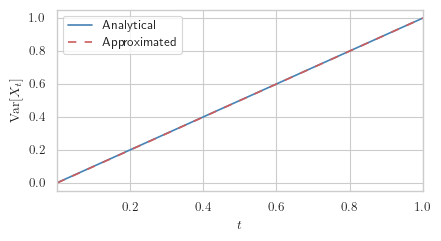

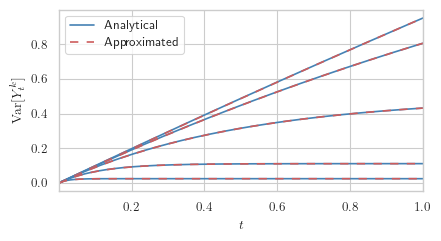

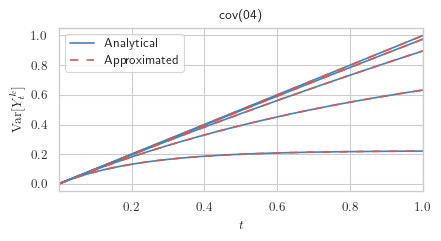

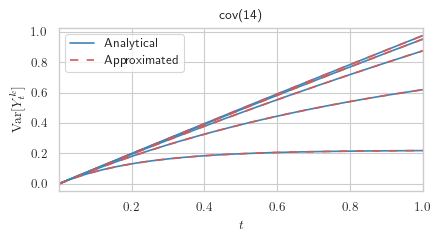

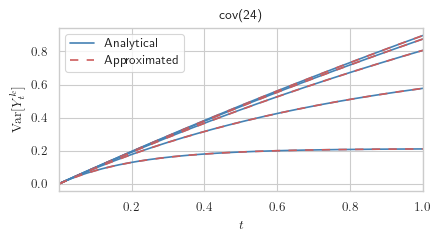

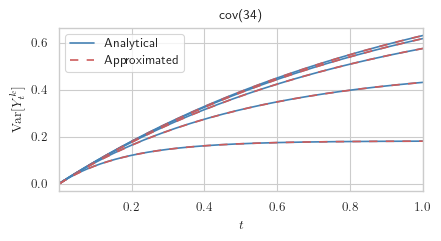

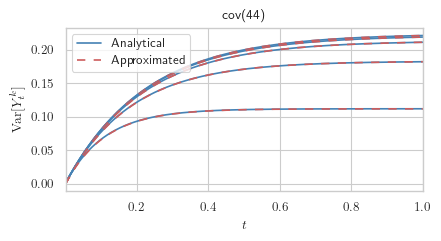

In [76]:
import seaborn as sns
sns.set(font_scale=6., rc={'text.usetex' : True}, style='whitegrid')
sns.set_context('paper')

t = torch.arange(1000+1)/1000
t = t[1:][:,None]
print('t',t.shape)
sigma_t = covZ(t, t, omega, gamma, g_max)[:,0,:,:]
print('sigma',sigma_t.shape)
ts = np.linspace(0., 1., 1000)
sigma_t_approx = np.stack([get_result(t,num_k,gamma) for t in ts])
print('sigma_t_approx',sigma_t_approx.shape)

fig, ax = plt.subplots(figsize=(4.5, 2.5), tight_layout=True)
ax.plot(t, sigma_t[:, 0, 0], color='steelblue')
ax.plot(t, sigma_t_approx[:, 0, 0], linestyle=(0, (5, 5)), color='indianred')
ax.legend(['Analytical', 'Approximated'], loc='upper left', )
ax.set_xlabel('$t$')
ax.set_ylabel('$\\mathrm{Var}[X_t]$')
ax.set_xlim(t.min(), t.max())
plt.show()


fig, ax = plt.subplots(figsize=(4.5, 2.5), tight_layout=True)
for k in range(num_k):
    ax.plot(t, sigma_t[:, k+1, k+1], color='steelblue')
    ax.plot(t, sigma_t_approx[:, k+1, k+1], linestyle=(0, (5, 5)), color='indianred')

ax.legend(['Analytical', 'Approximated'], loc='upper left', )
ax.set_xlabel('$t$')
ax.set_ylabel('$\\mathrm{Var}[Y^{k}_t]$')
ax.set_xlim(t.min(), t.max())
plt.show()

for j in range(num_k):
    fig, ax = plt.subplots(figsize=(4.5, 2.5), tight_layout=True)
    plt.title(f'cov({j}{k})')
    for k in range(num_k):
        ax.plot(t, sigma_t[:, j, k], color='steelblue')
        ax.plot(t, sigma_t_approx[:, j, k], linestyle=(0, (5, 5)), color='indianred')

    ax.legend(['Analytical', 'Approximated'], loc='upper left', )
    ax.set_xlabel('$t$')
    ax.set_ylabel('$\\mathrm{Var}[Y^{k}_t]$')
    ax.set_xlim(t.min(), t.max())
    plt.show()

/tmp/ipykernel_36515/1141996217.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dt = torch.tensor(T/N)


normalize variance with 1.0
dtype torch.float32
g_max=1.0
tensor(5.8455)
tensor(-0.8451)


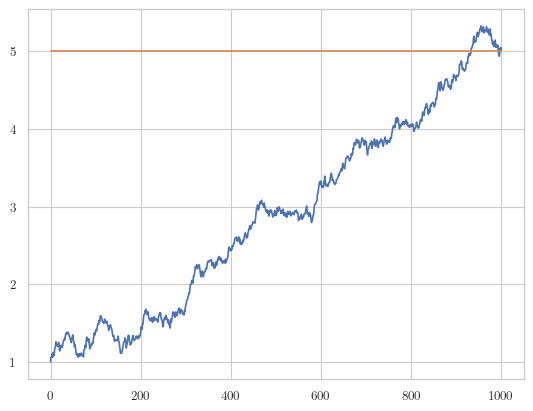

In [77]:
start = 0.0
end = 1.0

T = torch.tensor([[1.0]]) * end
N = 1000
dt = torch.tensor(T/N)
bs = 1000
K = 5
H = 0.5
gamma_min = None
gamma_max = 20.0

a = 1.0
b = 5.0

x0 = torch.ones(bs,2) * a
xT = torch.ones(bs,2) * b

fbb = FractionalSchrödingerBridge(H=H, K=K, gamma_min=gamma_min,gamma_max=gamma_max)

omega = fbb.omega 
gamma = fbb.gamma

g_max = 1.0

F = torch.zeros(K+1,K+1)
F[:,1:] = -torch.vstack([g_max*(omega * gamma)[0],torch.diag(gamma[0])])

G = torch.ones(K+1)
G[0] = torch.sum(omega) * g_max

Z = torch.ones(bs,2,N+1,K+1)
Z[:,:,:,1:] = 0
z0 =  Z[:,:,0,:]
timesteps = torch.linspace(start, end, N+2)


for n in range(N):

    t = timesteps[n+1][None,None]
    GG = G[None,None,:,None] * G[None,None,None,:]
    dw = torch.sqrt(dt) * torch.randn_like(z0[:,:,0])[:,:,None]
    x = z0[:,:,0]
    Y = z0[:,:,1:]

    score = score_fn(t,T,x,Y,xT,omega, gamma, g_max)
    z1 = z0 + (matrix_vector_mp(F[None,None,:,:], z0) + matrix_vector_mp(GG, score))*dt + G[None,None,:] * dw
    
    Z[:,:,n+1] = z1

    if torch.isnan(Z).any():
        print(f'Found nan in Z at t={t[0,0]}')
        break

    z0 = z1

print(torch.max(Z))
print(torch.min(Z))
plt.plot(Z[0,0,:,0])
plt.plot(torch.ones_like(Z[0,0,:,0])*b)


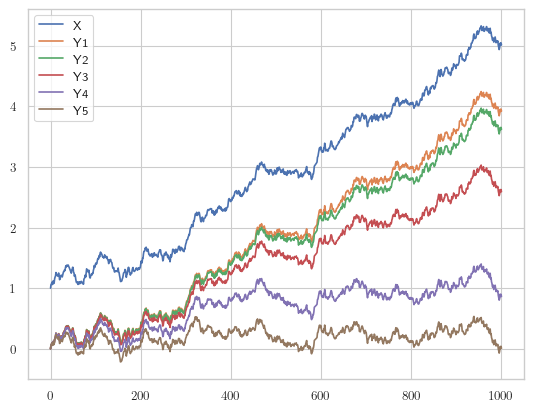

In [78]:
plt.plot(Z[0,0,:,0],label=f'X')
for k in range(K):
    plt.plot(Z[0,0,:,k+1],label=f'Y{k+1}')

plt.legend()

In [79]:
# Z = torch.ones(bs,2,N+1,K+1)
# Z[:,:,:,1:] = 0
# z0 =  Z[:,:,0,:]
# timesteps = torch.linspace(start, end, N+2)


# for n in range(N):

#     t0 = timesteps[n][None] * torch.ones(bs)
#     t1 = timesteps[n+1][None] * torch.ones(bs)
#     x = z0[:,:,0]
#     Y = z0[:,:,1:]
#     mu = meanZ(t0,t1,x,Y,omega,gamma,g_max)
#     cov = covZ(t1,t1,omega, gamma, g_max, s=t0, eps=1e-4)
#     dz = mu + sample_from_batch_multivariate_normal(cov,c=x.shape[1],h=1,w=1,batch_size=bs, aug_dim=K+1)[:,:,0,0,:]
#     z1 = z0 + dz
    
#     Z[:,:,n+1] = z1

#     if torch.isnan(Z).any():
#         print(f'Found nan in Z at t={t[0,0]}')
#         break

#     z0 = z1

# print(torch.max(Z))
# print(torch.min(Z))
# plt.plot(Z[0,0,:,0])
# plt.plot(torch.ones_like(Z[0,0,:,0])*b)

In [80]:
from scipy.stats import wasserstein_distance

max_wsd = -float('inf')
min_wsd = float('inf')
mean_wsd = 0.0
for _ in range(N):

    y1 = torch.randn(10000)
    y2 = torch.randn(10000)

    distance = wasserstein_distance(y1,y2)

    if max_wsd<distance:
        max_wsd=distance
    if min_wsd>distance:
        min_wsd=distance

    mean_wsd += distance

mean_wsd = mean_wsd/N

print('max_wsd:',max_wsd)
print('min_wsd:',min_wsd)
print('mean_wsd:',mean_wsd)

max_wsd: 0.05173277073596018
min_wsd: 0.007925583716807877
mean_wsd: 0.018322402573593362


In [83]:
Z_hat = torch.ones(bs,2,N+1,K+1)
Z_hat[:,:,:,1:] = 0
z0 =  Z[:,:,0,:]
wsd = torch.zeros(N+1,K+1)

timesteps = torch.linspace(start, end, N+2)
for n in range(N):
    t = timesteps[n+1] * torch.ones(bs,1)
    Z_hat[:,:,n+1,:] = sample_pinned(t,T,x0,xT,omega,gamma,g_max)
    #wsd[n+1,0] = wasserstein_distance(Z_hat[:,0,n+1,0],Z[:,0,n+1,0])
    for k in range(K+1):
        wsd[n+1,k] = wasserstein_distance(Z_hat[:,0,n+1,k],Z[:,0,n+1,k])

print('minimal distance',torch.min(wsd))
print('maximal distance',torch.max(wsd))
print('average distance',torch.mean(wsd))
               
#print('minimal distance',torch.min(wsd[:,0]))
#print('maximal distance',torch.max(wsd[:,0]))
#print('average distance',torch.mean(wsd[:,0]))

cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 1000
cov_matrix torch.Size([1000, 6, 6])
c 1
h 1
w 1
batch 10